<a href="https://colab.research.google.com/github/ashnagibbons/MAT328Midterm/blob/main/MAT328MidtermProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Two ways to download the CSV file (method two at the end of the notebook)**

1. From Kaggle

- Go to https://www.kaggle.com/datasets/kanchana1990/real-estate-data-oregon-2026 and download the main csv file. Save it to your comptuer

- Run the cell below. When the button saying choose files comes up, select the file you just downloaded from your computer

In [2]:
from google.colab import files
uploaded = files.upload()

Saving oregon_real_estate_2026_ultimate.csv to oregon_real_estate_2026_ultimate.csv


- Run this cell to load the file into a pandas dataframe

In [3]:
import io
df = pd.read_csv(io.BytesIO(uploaded['oregon_real_estate_2026_ultimate.csv']))

In [4]:
df

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Showings subject to accepted offer. Investor o...,179950.0,698.0,1.0,2.0,1.0,1.0,1.0,NaN,1897.0
1,single_family,NaN,*DO NOT DRIVE BY WITHOUT AN APPOINTMENT* Distr...,399900.0,2736.0,2.0,4.0,2.0,2.0,2.0,2.0,1990.0
2,condos,condo,This exceptional property is priced to sell & ...,220000.0,1130.0,1.0,3.0,3.0,3.0,3.0,NaN,2011.0
3,single_family,NaN,Commercially zoned property currently utilized...,230000.0,1293.0,2.0,3.0,2.0,2.0,2.0,1.0,1956.0
4,condos,condo,Sophisticated and beautifully updated riverfro...,899000.0,3172.0,3.0,3.0,4.0,4.0,4.0,1.0,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10398,townhomes,townhouse,"New Construction, Brynhill Community, Daphne F...",329900.0,1441.0,2.0,3.0,2.0,2.0,2.0,2.0,2026.0
10399,single_family,NaN,Light and bright bungalow on .25 acre lot. (Zo...,415000.0,1238.0,2.0,2.0,1.0,1.0,1.0,1.0,1953.0
10400,single_family,NaN,This is one of the very best floating home loc...,750000.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
10401,townhomes,townhouse,Live new without the new-construction wait in ...,387500.0,1332.0,2.0,2.0,2.0,2.0,2.0,1.0,2025.0


In [5]:
df['sub_type'].value_counts()

,count
sub_type,
condo,859
townhouse,486


In [6]:
df.isna().sum()

,0
type,0
sub_type,9058
text,19
listPrice,0
sqft,2076
stories,2214
beds,2069
baths,2002
baths_full,2092
baths_full_calc,2090


In [7]:
no_land = df[df['type'] != 'land']
no_land.isna().sum()
#len(no_land)

,0
type,0
sub_type,7186
text,15
listPrice,0
sqft,204
stories,342
beds,197
baths,321
baths_full,220
baths_full_calc,218


In [8]:
new_df = no_land.drop(columns=['sub_type'])

In [9]:
print(len(new_df))
new_df.isna().sum()

8531


,0
type,0
text,15
listPrice,0
sqft,204
stories,342
beds,197
baths,321
baths_full,220
baths_full_calc,218
garage,1914


In [10]:
new_df = new_df.dropna()
len(new_df)

6200

In [11]:
new_df.isna().sum()

,0
type,0
text,0
listPrice,0
sqft,0
stories,0
beds,0
baths,0
baths_full,0
baths_full_calc,0
garage,0


In [12]:
new_df['type'].value_counts()

,count
type,
single_family,5174
condos,510
townhomes,409
multi_family,77
farm,30


In [13]:
new_df.columns

Index(['type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths',
       'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

Text(0, 0.5, 'Number of Properties')

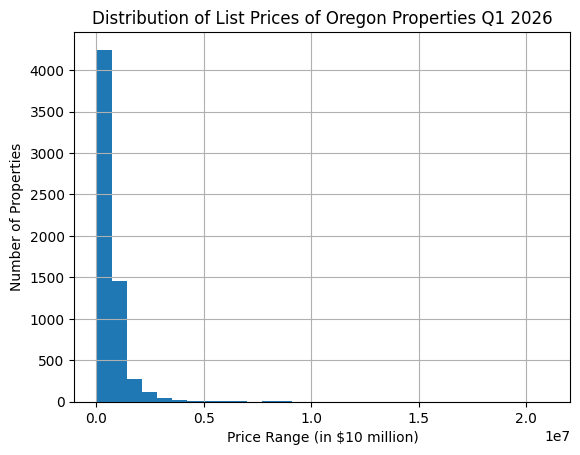

In [14]:
new_df['listPrice'].hist(bins=30)
plt.title('Distribution of List Prices of Oregon Properties Q1 2026')
plt.xlabel('Price Range (in $10 million)')
plt.ylabel('Number of Properties')

In [15]:
new_df['listPrice'].mean()

np.float64(763894.9879032258)

In [16]:
new_df['listPrice'].median()

575000.0

In [17]:
land = df[df['type'] == 'land']
print(len(land))
land.isna().sum()

1872


,0
type,0
sub_type,1872
text,4
listPrice,0
sqft,1872
stories,1872
beds,1872
baths,1681
baths_full,1872
baths_full_calc,1872


In [18]:
land.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

In [19]:
land = land.drop(columns=['sub_type', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'])

Text(0, 0.5, 'Number of Properties')

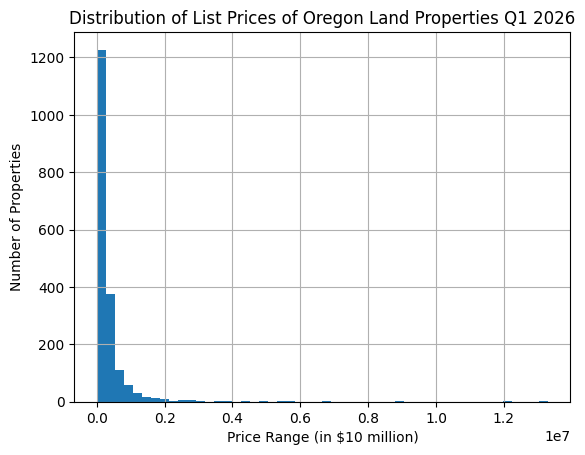

In [20]:
land['listPrice'].hist(bins=50)
plt.title('Distribution of List Prices of Oregon Land Properties Q1 2026')
plt.xlabel('Price Range (in $10 million)')
plt.ylabel('Number of Properties')

In [21]:
land['listPrice'].mean()

np.float64(348320.69177350425)

In [22]:
land['listPrice'].median()

183500.0

Text(0, 0.5, 'Number of Properties')

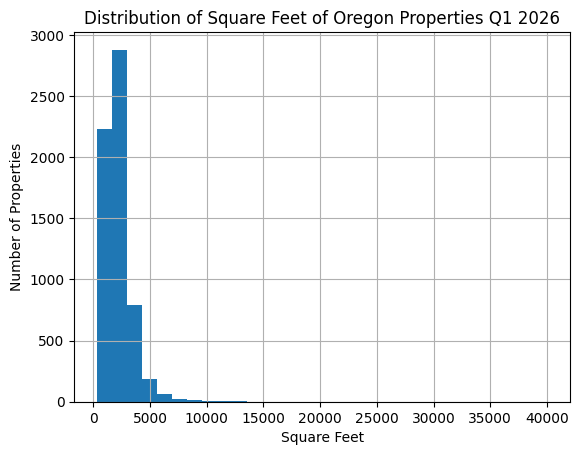

In [23]:
new_df['sqft'].hist(bins=30)
plt.title('Distribution of Square Feet of Oregon Properties Q1 2026')
plt.xlabel('Square Feet')
plt.ylabel('Number of Properties')

In [24]:
print(new_df['sqft'].mean())
print(new_df['sqft'].median())
print(new_df['sqft'].max())

2211.075806451613
1912.5
40075.0


Text(0, 0.5, 'Number of Properties')

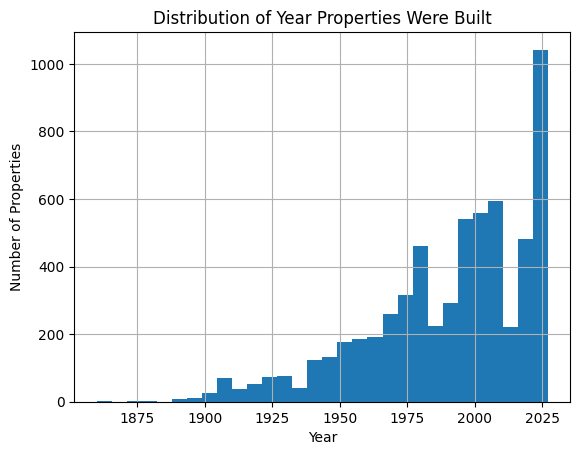

In [25]:
new_df['year_built'].hist(bins=30)
plt.title('Distribution of Year Properties Were Built')
plt.xlabel('Year')
plt.ylabel('Number of Properties')

Text(0, 0.5, 'Frequency')

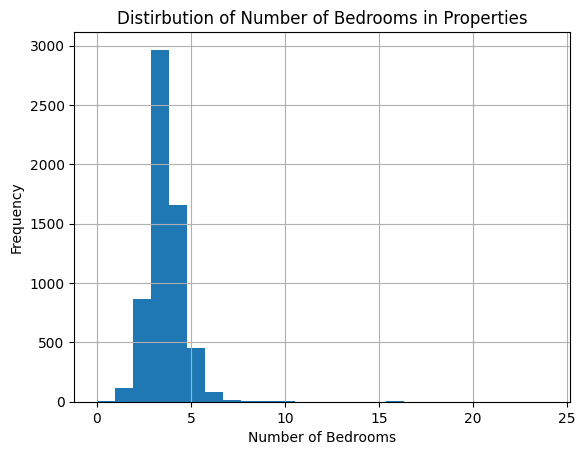

In [26]:
new_df['beds'].hist(bins=25)
plt.title('Distirbution of Number of Bedrooms in Properties')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Frequency')

In [27]:
new_df['beds'].max()

24.0

Text(9.444444444444445, 0.5, 'List Price (in $10 Million)')

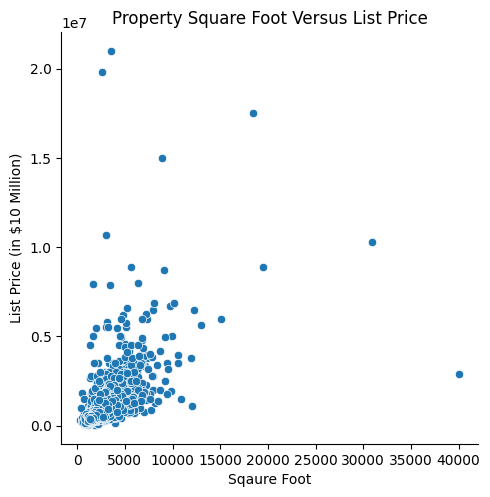

In [28]:
sns.relplot(x='sqft', y='listPrice', data=new_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $10 Million)')

Text(0, 0.5, 'List Price (in $10 Million)')

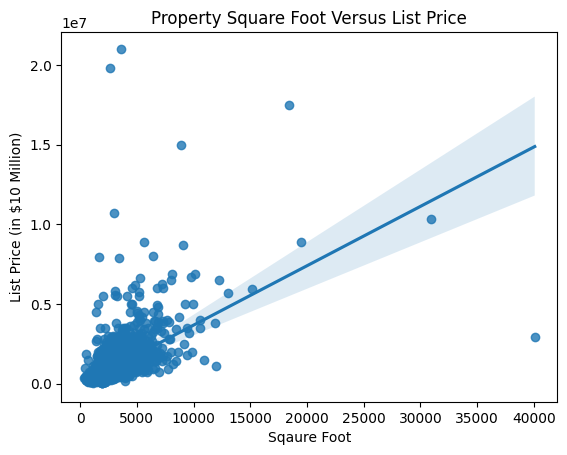

In [29]:
sns.regplot(x='sqft', y='listPrice', data=new_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $10 Million)')

Text(9.444444444444445, 0.5, 'List Price (in $10 Million)')

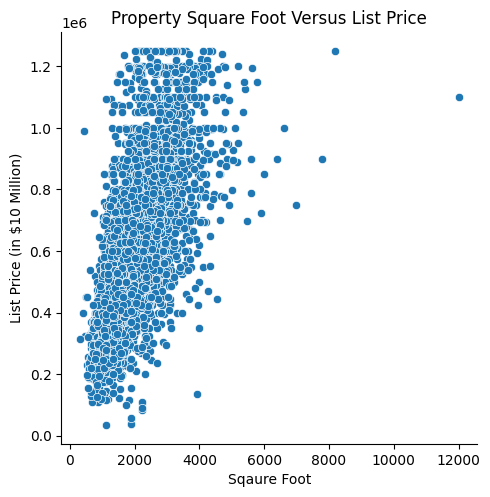

In [30]:
price_filter = new_df['listPrice'] <= 1250000
sqft_filter = new_df['sqft'] <= 20000
zoomed_df = new_df[price_filter & sqft_filter]

sns.relplot(x='sqft', y='listPrice', data=zoomed_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $10 Million)')

Text(0, 0.5, 'List Price (in $1 Million)')

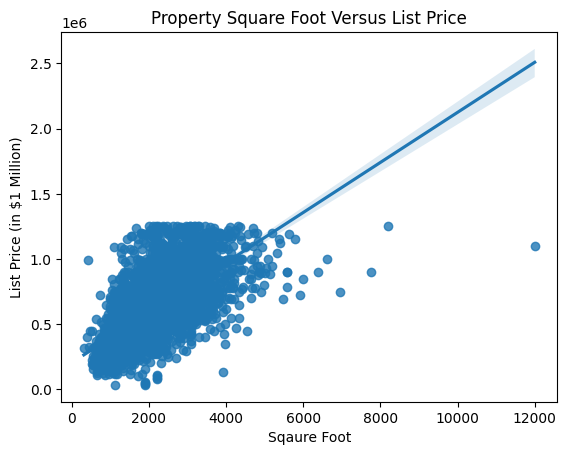

In [35]:
sns.regplot(x='sqft', y='listPrice', data=zoomed_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $1 Million)')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '2.0'),
  Text(3, 0, '3.0'),
  Text(4, 0, '4.0'),
  Text(5, 0, '5.0'),
  Text(6, 0, '6.0'),
  Text(7, 0, '7.0'),
  Text(8, 0, '8.0'),
  Text(9, 0, '9.0'),
  Text(10, 0, '10.0'),
  Text(11, 0, '11.0'),
  Text(12, 0, '12.0'),
  Text(13, 0, '13.0'),
  Text(14, 0, '16.0'),
  Text(15, 0, '17.0'),
  Text(16, 0, '24.0')])

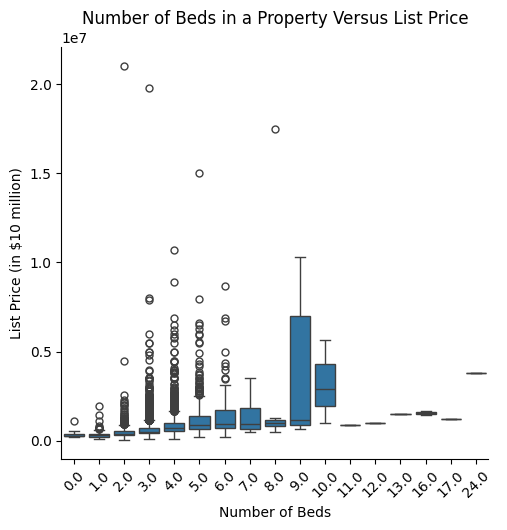

In [36]:
sns.catplot(x='beds', y='listPrice', kind='box', data=new_df)
plt.title('Number of Beds in a Property Versus List Price')
plt.xlabel('Number of Beds')
plt.ylabel('List Price (in $10 million)')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '2.0'),
  Text(3, 0, '3.0'),
  Text(4, 0, '4.0'),
  Text(5, 0, '5.0'),
  Text(6, 0, '6.0'),
  Text(7, 0, '7.0'),
  Text(8, 0, '8.0'),
  Text(9, 0, '9.0'),
  Text(10, 0, '10.0')])

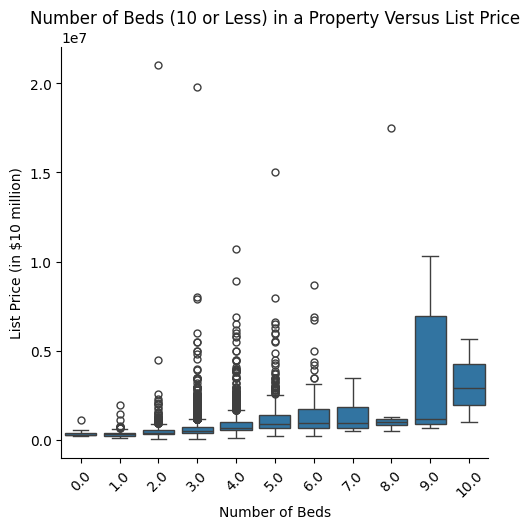

In [38]:
low_beds_df = new_df[new_df['beds'] < 11]

sns.catplot(x='beds', y='listPrice', kind='box', data=low_beds_df)
plt.title('Number of Beds (10 or Less) in a Property Versus List Price')
plt.xlabel('Number of Beds')
plt.ylabel('List Price (in $10 million)')
plt.xticks(rotation=45)

2. From my GitHub

- Go to https://github.com/ashnagibbons/MAT328Midterm/blob/main/oregon_real_estate_2026_ultimate.csv and press the button that says Raw in the top right of the file

- Copy the url of the new page it takes you to and paste it in the variable called url in the cell below. Then run the cell

(Note: I am having trouble getting a static raw file on GitHub so if you don't go to my GitHub page and get the raw url yourself, it will give you a 404 error)

In [34]:
url = 'your url'

df2 = pd.read_csv(url)

FileNotFoundError: [Errno 2] No such file or directory: 'your url'